In [1]:
pwd

'C:\\Users\\hp'

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("03_Clustering_Marketing.csv")

df.head()

,gradyear,gender,age,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
0,2007,NaN,NaN,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2007,F,17.41,49,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,1,0
2,2007,F,17.511,41,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,1
3,2006,F,NaN,36,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2008,F,16.657,1,0,0,0,0,0,1,...,0,0,0,3,0,0,0,0,0,0


In [4]:
df.shape

(15000, 40)

In [5]:
df.columns

Index(['gradyear', 'gender', 'age', 'NumberOffriends', 'basketball',
       'football', 'soccer', 'softball', 'volleyball', 'swimming',
       'cheerleading', 'baseball', 'tennis', 'sports', 'cute', 'sex', 'sexy',
       'hot', 'kissed', 'dance', 'band', 'marching', 'music', 'rock', 'god',
       'church', 'jesus', 'bible', 'hair', 'dress', 'blonde', 'mall',
       'shopping', 'clothes', 'hollister', 'abercrombie', 'die', 'death',
       'drunk', 'drugs'],
      dtype='object')

In [6]:
df.dtypes

gradyear            int64
gender             object
age                object
NumberOffriends     int64
basketball          int64
football            int64
soccer              int64
softball            int64
volleyball          int64
swimming            int64
cheerleading        int64
baseball            int64
tennis              int64
sports              int64
cute                int64
sex                 int64
sexy                int64
hot                 int64
kissed              int64
dance               int64
band                int64
marching            int64
music               int64
rock                int64
god                 int64
church              int64
jesus               int64
bible               int64
hair                int64
dress               int64
blonde              int64
mall                int64
shopping            int64
clothes             int64
hollister           int64
abercrombie         int64
die                 int64
death               int64
drunk       

In [7]:
df.isnull().sum().sort_values(ascending=False)

age                2496
gender             1337
gradyear              0
NumberOffriends       0
basketball            0
football              0
soccer                0
softball              0
volleyball            0
swimming              0
cheerleading          0
baseball              0
tennis                0
sports                0
cute                  0
sex                   0
sexy                  0
hot                   0
kissed                0
dance                 0
band                  0
marching              0
music                 0
rock                  0
god                   0
church                0
jesus                 0
bible                 0
hair                  0
dress                 0
blonde                0
mall                  0
shopping              0
clothes               0
hollister             0
abercrombie           0
die                   0
death                 0
drunk                 0
drugs                 0
dtype: int64

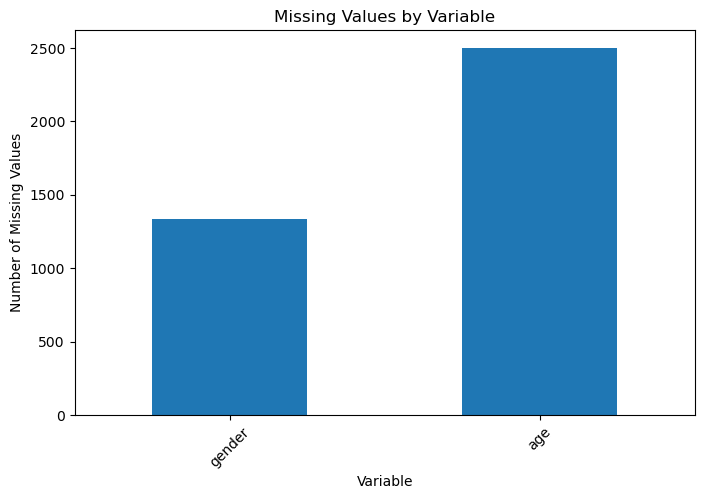

In [8]:
missing = df.isnull().sum()
missing = missing[missing > 0]

plt.figure(figsize=(8,5))
missing.plot(kind='bar')
plt.title("Missing Values by Variable")
plt.ylabel("Number of Missing Values")
plt.xlabel("Variable")
plt.xticks(rotation=45)
plt.show()

In [9]:
df['gender'].value_counts(dropna=False)

gender
F      11057
M       2606
NaN     1337
Name: count, dtype: int64

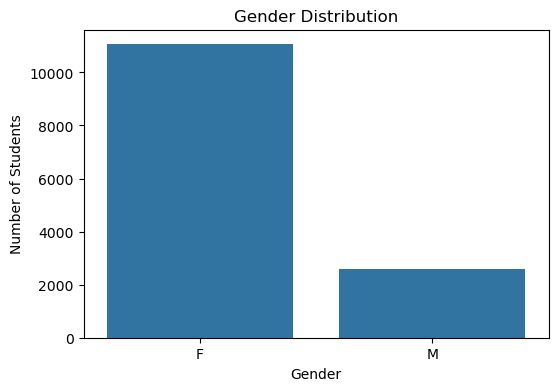

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='gender')

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Students")
plt.show()

In [11]:
df['age_num']=pd.to_numeric(df['age'],errors='coerce')

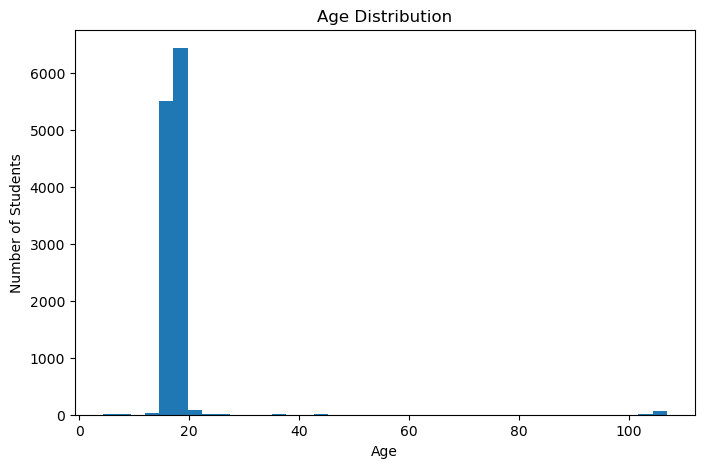

In [12]:
plt.figure(figsize=(8,5))

plt.hist(df['age_num'].dropna(), bins=40)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Students")

plt.show()

In [13]:
df['age_num'].describe()

count    12228.000000
mean        17.988164
std          7.715857
min          4.309000
25%         16.331000
50%         17.295000
75%         18.264000
max        106.927000
Name: age_num, dtype: float64

In [18]:
df.loc[(df['age_num'] < 13) | (df['age_num'] > 25),'age_num']=np.nan

In [19]:
df['age_num']=df['age_num'].fillna(df['age_num'].median())

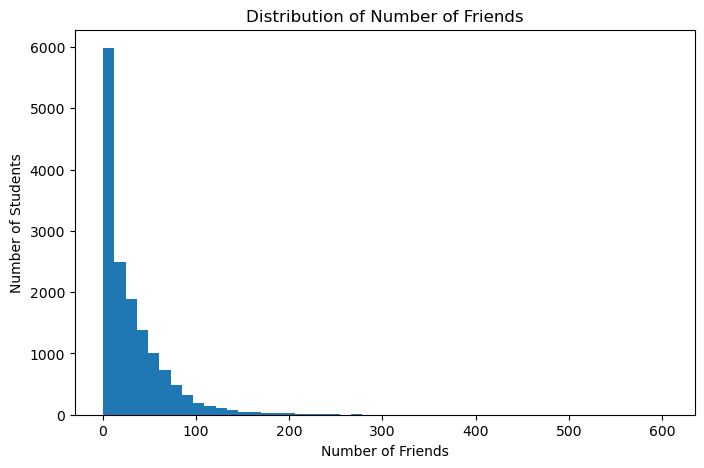

In [20]:
plt.figure(figsize=(8,5))

plt.hist(df['NumberOffriends'], bins=50)

plt.title("Distribution of Number of Friends")
plt.xlabel("Number of Friends")
plt.ylabel("Number of Students")

plt.show()

In [22]:
df['NumberOffriends'].describe()

count    15000.000000
mean        29.834533
std         35.386649
min          0.000000
25%          3.000000
50%         20.000000
75%         44.000000
max        605.000000
Name: NumberOffriends, dtype: float64

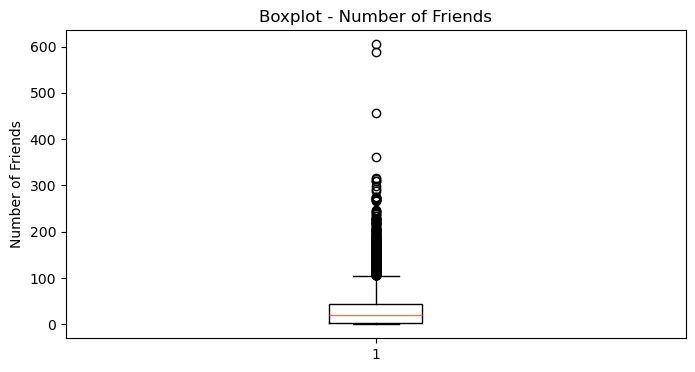

In [23]:
plt.figure(figsize=(8,4))

plt.boxplot(df['NumberOffriends'])

plt.title("Boxplot - Number of Friends")
plt.ylabel("Number of Friends")

plt.show()

In [25]:
numeric_cols=df.select_dtypes(include=np.number).columns
skewness=df[numeric_cols].skew().sort_values(ascending=False)
print(skewness)

blonde             117.250830
sex                 49.972125
bible               21.417635
jesus               19.160195
swimming            16.380904
kissed              12.866542
drugs               12.508258
marching            11.670519
god                 11.490218
tennis              11.236150
baseball             9.344208
abercrombie          8.169792
death                8.104098
softball             7.842373
hollister            7.788430
volleyball           7.548032
drunk                7.545941
band                 7.413696
soccer               7.277183
die                  6.993131
cheerleading         6.917809
sexy                 6.678510
rock                 6.450876
sports               5.877223
dance                5.728317
hot                  5.685510
basketball           5.681317
church               5.549156
dress                5.546623
mall                 4.697283
hair                 4.637419
clothes              4.572851
music                4.378561
cute      

In [26]:
interest_cols=[c for c in df.columns if c not in ['gradyear','gender','age','age_num','NumberOffriends']]
feature_cols=['age_num','NumberOffriends']+interest_cols

In [27]:
X=df[feature_cols].copy()
for col in feature_cols:
    if col!='age_num':
        X[col]=np.log1p(X[col])
        

In [28]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [29]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2, 8)

silhouette_scores = []

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

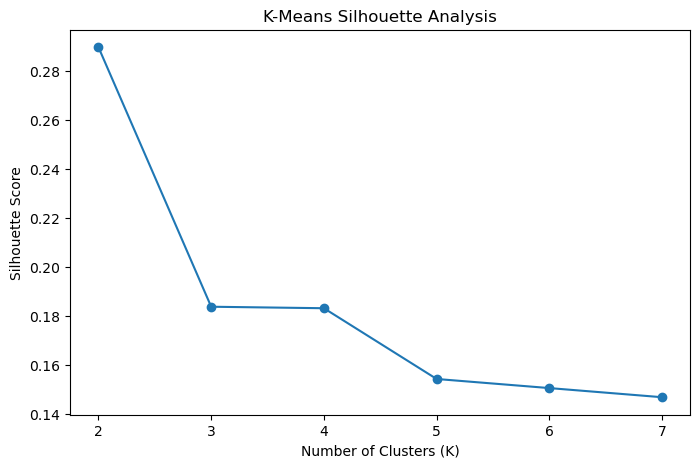

In [30]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    silhouette_scores,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("K-Means Silhouette Analysis")

plt.show()

In [31]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

In [32]:
df['kmeans_cluster'].value_counts()

kmeans_cluster
1    12246
0     2754
Name: count, dtype: int64

In [33]:
from sklearn.cluster import AgglomerativeClustering

sample_idx = np.random.RandomState(42).choice(
    len(X_scaled),
    size=5000,
    replace=False
)

X_sample = X_scaled[sample_idx]

In [34]:
hierarchical = AgglomerativeClustering(
    n_clusters=2,
    linkage='ward'
)

hier_labels = hierarchical.fit_predict(X_sample)

hier_score = silhouette_score(
    X_sample,
    hier_labels
)

print(hier_score)

0.24155039026587427


In [35]:
for k in range(2, 8):

    model = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'
    )

    labels = model.fit_predict(X_sample)

    score = silhouette_score(
        X_sample,
        labels
    )

    print(k, score)

2 0.24155039026587427
3 0.2204775330357167
4 0.2176509415964671
5 0.22318770505135307
6 0.16967411320619294
7 0.12877360098218996


In [36]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.1,
    min_samples=10,
    n_jobs=-1
)

db_labels = dbscan.fit_predict(X_sample)

In [37]:
mask = db_labels != -1

db_score = silhouette_score(
    X_sample[mask],
    db_labels[mask]
)

print(db_score)

0.2899621406252277


In [38]:
df.groupby('kmeans_cluster')[
    ['age_num', 'NumberOffriends']
].mean()

,age_num,NumberOffriends
kmeans_cluster,,
0,17.069147,38.935730
1,17.325620,27.787767


In [39]:
pd.crosstab(
    df['kmeans_cluster'],
    df['gender'],
    normalize='index'
)

gender,F,M
kmeans_cluster,,
0,0.919479,0.080521
1,0.783265,0.216735


In [40]:
cluster_profile = df.groupby(
    'kmeans_cluster'
)[interest_cols].mean()

cluster_profile

,basketball,football,soccer,softball,volleyball,swimming,cheerleading,baseball,tennis,sports,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
kmeans_cluster,,,,,,,,,,,,,,,,,,,,,
0,0.592593,0.523965,0.435367,0.346768,0.315178,0.304648,0.270516,0.212055,0.161946,0.340959,...,0.461511,0.684459,0.831881,0.517429,0.263980,0.206245,0.489107,0.270516,0.293391,0.25817
1,0.193778,0.195084,0.174016,0.117589,0.104197,0.096848,0.067941,0.079863,0.071615,0.099298,...,0.034460,0.163890,0.250531,0.067696,0.028581,0.016659,0.117671,0.083782,0.046382,0.01674


In [41]:
difference = (
    cluster_profile.loc[1] -
    cluster_profile.loc[0]
).abs().sort_values(
    ascending=False
)

difference.head(15)

hair          1.392778
music         0.799026
sex           0.756991
god           0.704971
dance         0.701573
cute          0.649585
shopping      0.581350
mall          0.520569
rock          0.458059
clothes       0.449734
kissed        0.444129
blonde        0.427050
church        0.415941
basketball    0.398815
band          0.393831
dtype: float64